# <span style="color:#1f4e79; font-weight:bold; font-size:30px;">📊 Retail Store Performance Analysis</span>

<img src="Captureretail.PNG" width="1000">

## <span style="color:#1f4e79; font-weight:bold; font-size:20px;">🎯 Project Objective</span>

This project analyzes retail store performance using Monthly Sales Revenue as the primary success indicator.
The objective is to understand how operational, marketing, customer, and external factors influence store outcomes, and to convert the analysis into meaningful business insights that support better retail decision-making.

🔎 Key Focus Areas :

- Operational factors: impact of product variety, employee efficiency, and store size on revenue
- Marketing effectiveness: how promotions and marketing spend relate to sales performance
- Customer behavior: whether higher footfall actually translates into higher revenue
- External environment: influence of competition distance and economic conditions on store success
- Performance patterns: identifying what differentiates high-performing stores from low-performing ones

## <span style="color:#1f4e79; font-weight:bold; font-size:20px;">📦 Importing Libraries</span>

In [2]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt 
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## <span style="color:#1f4e79; font-weight:bold; font-size:20px;">📂 Data Loading and Initial Overview</span>

In [3]:
df= pd.read_csv('Store_CA.csv')

#### <span style="color:#2e75b6; font-weight:bold;">Number of rows and columns</span>

In [3]:
df.shape

(1650, 12)

#### <span style="color:#2e75b6; font-weight:bold;">Data types of each column</span>

In [4]:
df.dtypes

ProductVariety           int64
MarketingSpend           int64
CustomerFootfall         int64
StoreSize                int64
EmployeeEfficiency     float64
StoreAge                 int64
CompetitorDistance       int64
PromotionsCount          int64
EconomicIndicator      float64
StoreLocation           object
StoreCategory           object
MonthlySalesRevenue    float64
dtype: object

#### <span style="color:#2e75b6; font-weight:bold;">Initial observations</span>

In [5]:
# Data types & structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1650 entries, 0 to 1649
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ProductVariety       1650 non-null   int64  
 1   MarketingSpend       1650 non-null   int64  
 2   CustomerFootfall     1650 non-null   int64  
 3   StoreSize            1650 non-null   int64  
 4   EmployeeEfficiency   1650 non-null   float64
 5   StoreAge             1650 non-null   int64  
 6   CompetitorDistance   1650 non-null   int64  
 7   PromotionsCount      1650 non-null   int64  
 8   EconomicIndicator    1650 non-null   float64
 9   StoreLocation        1650 non-null   object 
 10  StoreCategory        1650 non-null   object 
 11  MonthlySalesRevenue  1650 non-null   float64
dtypes: float64(3), int64(7), object(2)
memory usage: 154.8+ KB


In [6]:
# Initial look at dataset
df.head()

,ProductVariety,MarketingSpend,CustomerFootfall,StoreSize,EmployeeEfficiency,StoreAge,CompetitorDistance,PromotionsCount,EconomicIndicator,StoreLocation,StoreCategory,MonthlySalesRevenue
0,581,29,1723,186,84.9,1,12,6,108.3,Los Angeles,Electronics,284.90
1,382,31,1218,427,75.8,18,11,6,97.8,Los Angeles,Electronics,308.21
2,449,35,2654,142,92.8,14,11,6,101.1,Los Angeles,Grocery,292.11
3,666,9,2591,159,66.3,11,11,4,115.1,Sacramento,Clothing,279.61
4,657,35,2151,275,89.1,28,12,7,93.4,Palo Alto,Electronics,359.71


In [7]:
# Summary Statistics
df.describe()

,ProductVariety,MarketingSpend,CustomerFootfall,StoreSize,EmployeeEfficiency,StoreAge,CompetitorDistance,PromotionsCount,EconomicIndicator,MonthlySalesRevenue
count,1650.000000,1650.000000,1650.000000,1650.000000,1650.000000,1650.000000,1650.000000,1650.000000,1650.000000,1650.000000
mean,500.915758,27.460000,2020.028485,272.997576,72.198545,15.447879,9.933939,5.500606,99.761939,299.253285
std,148.054223,13.014753,484.025786,131.048595,13.019817,8.667779,3.117450,1.388356,14.614712,65.543755
min,100.000000,5.000000,500.000000,50.000000,50.000000,1.000000,1.000000,3.000000,60.000000,106.710000
25%,396.000000,17.000000,1691.000000,156.000000,61.000000,8.000000,8.000000,4.000000,90.000000,254.125000
50%,500.500000,27.000000,2021.000000,273.000000,72.100000,16.000000,10.000000,5.000000,100.300000,297.440000
75%,602.750000,38.000000,2350.750000,385.500000,83.100000,23.000000,12.000000,7.000000,109.600000,344.222500
max,1092.000000,50.000000,3627.000000,500.000000,94.900000,30.000000,20.000000,8.000000,140.000000,534.260000


## <span style="color:#1f4e79; font-weight:bold; font-size:20px;">🧹 Data Pre-processing</span>

#### <span style="color:#2e75b6; font-weight:bold;">Handling missing values</span>

In [8]:
df.isnull().sum()

ProductVariety         0
MarketingSpend         0
CustomerFootfall       0
StoreSize              0
EmployeeEfficiency     0
StoreAge               0
CompetitorDistance     0
PromotionsCount        0
EconomicIndicator      0
StoreLocation          0
StoreCategory          0
MonthlySalesRevenue    0
dtype: int64

**Observation**

- A null value check was performed across all columns, and *no missing values* were found.
- Therefore, no imputation or row removal was required.

#### <span style="color:#2e75b6; font-weight:bold;">Removing duplicates</span>

In [9]:
df.duplicated().sum()

np.int64(0)

**Observation**

- Duplicate records were checked across the dataset, and *no duplicate rows* were identified. 


In [10]:
df.dtypes

ProductVariety           int64
MarketingSpend           int64
CustomerFootfall         int64
StoreSize                int64
EmployeeEfficiency     float64
StoreAge                 int64
CompetitorDistance       int64
PromotionsCount          int64
EconomicIndicator      float64
StoreLocation           object
StoreCategory           object
MonthlySalesRevenue    float64
dtype: object

**Observation**

- Data types were verified and ensured numerical and categorical columns are already in the appropriate format for analysis.

#### <span style="color:#2e75b6; font-weight:bold;">Creating derived columns</span> 

##### <span style="color:#2e75b6; font-weight:bold;">StoreAgeGroup</span>

In [9]:
df['StoreAgeGroup'] = pd.cut(
    df['StoreAge'],
    bins=[0, 5, 15, 30],
    labels=['Low', 'Mid', 'High']
)

**Observation**

- New column *StoreAgeGroup* is created on the  basis of years of establishment dividing the column StoreAge into - Low, Mid and High

##### <span style="color:#2e75b6; font-weight:bold;">SizeBand</span>

In [7]:
df['SizeBand'] = pd.cut(df['StoreSize'],
                        bins=[50, 200, 350, 500],
                        labels=['Small', 'Medium', 'Large']
                        )

**Observation**

- New column *SizeBand* is created on the  basis of store size which divides the store size column into - Small, Medium and Large

#### <span style="color:#2e75b6; font-weight:bold;">Filtering or aggregating data</span>

##### <span style="color:#2e75b6; font-weight:bold;">Aggregation by Store Location</span>

In [12]:
df.groupby('StoreLocation')['MonthlySalesRevenue'].mean()

StoreLocation
Los Angeles      301.191343
Palo Alto        298.366143
Sacramento       298.006505
San Francisco    299.414082
Name: MonthlySalesRevenue, dtype: float64

**Observation**

- Monthly Sales Revenue is grouped by location and no significant changes in sales of all locations.
- This indicates that location does not strongly influence overall sales performance.

##### <span style="color:#2e75b6; font-weight:bold;">Aggregation by Promotions Count</span>

In [20]:
df.groupby('PromotionsCount')['MonthlySalesRevenue'].mean()

PromotionsCount
3    299.203223
4    297.359939
5    299.414109
6    305.020650
7    295.294913
8    298.296379
Name: MonthlySalesRevenue, dtype: float64

**Observation**

- Monthly sales revenue remains fairly consistent across different promotion counts.
-  This indicates that increasing promotions alone does not significantly boost sales.

##### <span style="color:#2e75b6; font-weight:bold;">Filtering the stores with higher customer footfall but lower sales</span>

In [21]:
df[(df['CustomerFootfall'] > df['CustomerFootfall'].quantile(0.90)) & 
   (df['MonthlySalesRevenue'] < df['MonthlySalesRevenue'].quantile(0.10))]

,ProductVariety,MarketingSpend,CustomerFootfall,StoreSize,EmployeeEfficiency,StoreAge,CompetitorDistance,PromotionsCount,EconomicIndicator,StoreLocation,StoreCategory,MonthlySalesRevenue,SizeBand,MarketingBand
32,331,7,2893,110,82.1,27,7,4,87.3,Palo Alto,Electronics,203.15,Small,Low Spend
110,100,47,2729,257,92.9,27,13,7,96.1,San Francisco,Grocery,176.83,Medium,High Spend
125,233,28,2749,336,80.3,17,10,5,82.5,Sacramento,Electronics,192.54,Medium,Mid Spend
145,192,48,2984,248,81.9,11,12,8,106.9,Sacramento,Electronics,160.80,Medium,High Spend
224,305,37,2799,98,52.0,5,10,6,104.5,San Francisco,Grocery,194.53,Small,High Spend
262,321,13,2656,268,73.1,25,11,5,67.1,Los Angeles,Grocery,213.90,Medium,Low Spend
564,468,31,2753,60,90.4,2,12,6,123.6,Los Angeles,Clothing,211.54,Small,Mid Spend
810,340,23,2742,134,64.1,29,17,5,104.2,San Francisco,Clothing,183.24,Small,Mid Spend
843,132,35,2766,137,79.5,16,9,7,92.9,Palo Alto,Clothing,106.71,Small,Mid Spend
1043,291,31,2857,90,77.4,7,19,5,104.9,Los Angeles,Grocery,197.82,Small,Mid Spend


**Observation**

- Some stores with very high customer footfall still generate low sales.
- This suggests that high traffic does not necessarily convert into revenue and performance.

##### <span style="color:#2e75b6; font-weight:bold;">Filtering the stores with higher employer efficiency but lower sales</span>

In [4]:
df[(df['EmployeeEfficiency'] > df['EmployeeEfficiency'].quantile(0.90)) & 
   (df['MonthlySalesRevenue'] < df['MonthlySalesRevenue'].quantile(0.10))]

,ProductVariety,MarketingSpend,CustomerFootfall,StoreSize,EmployeeEfficiency,StoreAge,CompetitorDistance,PromotionsCount,EconomicIndicator,StoreLocation,StoreCategory,MonthlySalesRevenue
9,419,48,1949,90,93.1,16,5,8,110.3,Palo Alto,Electronics,203.93
50,123,41,2450,201,93.0,8,14,7,116.2,San Francisco,Electronics,193.79
110,100,47,2729,257,92.9,27,13,7,96.1,San Francisco,Grocery,176.83
515,381,26,1732,134,93.4,7,14,6,98.3,Sacramento,Grocery,188.08
552,366,50,1793,103,91.9,8,10,8,76.0,San Francisco,Electronics,202.62
575,310,32,1538,118,94.9,3,6,6,105.0,Sacramento,Grocery,162.95
665,147,37,1799,166,94.6,25,17,6,73.2,San Francisco,Clothing,195.55
666,150,27,1968,320,92.7,13,10,5,93.8,Los Angeles,Clothing,172.99
866,370,24,1452,60,93.0,2,15,6,104.5,Los Angeles,Grocery,197.06
1035,324,12,1450,205,93.4,10,14,4,78.3,Sacramento,Grocery,186.26


**Observation**

- Several stores show very high employee efficiency but still record low sales, indicating that staff performance alone does not drive revenue and other factors such as product mix, pricing, or demand may be limiting sales.

## <span style="color:#1f4e79; font-weight:bold; font-size:20px;">📊 Exploratory Data Analysis (EDA) and Visualizations</span>

### <span style="color:#2e75b6; font-weight:bold;">Univariate Analysis</span>

#### <span style="color:#2e75b6; font-weight:bold;">Density Plot: Distribution of Monthly Sales Revenue</span>

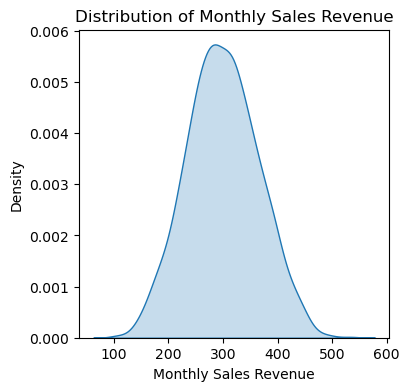

In [33]:
plt.figure(figsize=(4,4))
sns.kdeplot(data=df, x='MonthlySalesRevenue', fill=True)

plt.title('Distribution of Monthly Sales Revenue')
plt.xlabel('Monthly Sales Revenue')
plt.ylabel('Density')
plt.show()

**Observation**
- Monthly sales revenue is concentrated in the mid-range (200-400), with most stores showing consistent sales levels.
- Very few stores exhibit extremely low or high revenue values.

#### <span style="color:#2e75b6; font-weight:bold;">Bar Plot: Distribution of Stores by  SizeBand</span>

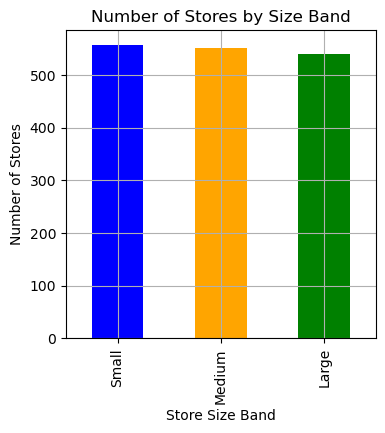

In [7]:
plt.figure(figsize=(4,4))
df['SizeBand'].value_counts().plot(kind='bar',color=['blue','orange','green'])
plt.title('Number of Stores by Size Band')
plt.xlabel('Store Size Band')
plt.ylabel('Number of Stores')
plt.grid('True')
plt.show()

**Observation**
- The dataset contains a nearly balanced distribution of stores across Small, Medium, and Large size bands.
-  This indicates that the sales comparisons across size categories are unlikely to be biased by unequal sample representation.

#### <span style="color:#2e75b6; font-weight:bold;">Pie Chart: Distribution of Stores by Category</span>

In [15]:
category_counts = df['StoreCategory'].value_counts()

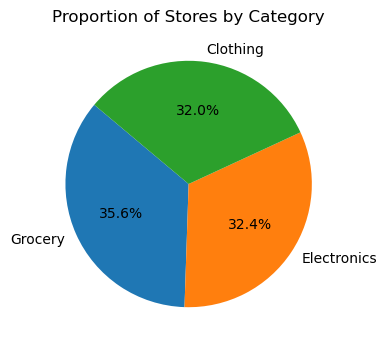

In [16]:
plt.figure(figsize=(4,4))
plt.pie(category_counts,
        labels=category_counts.index,
        autopct='%1.1f%%',
        startangle=140)

plt.title("Proportion of Stores by Category")
plt.show()

**Observation**

- Store distribution across categories is fairly balanced with *Grocery* forming the largest share (~36%).

### <span style="color:#2e75b6; font-weight:bold;">Bivariate Analysis</span>

#### <span style="color:#2e75b6; font-weight:bold;">Box Plot: Monthly Sales Revenue by Store Age Group</span>

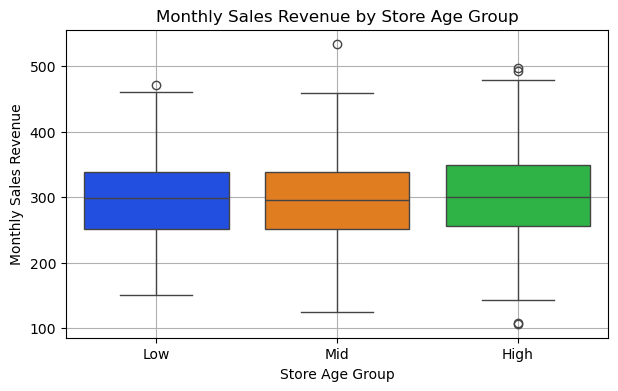

In [32]:
plt.figure(figsize=(7,4))
sns.boxplot(x='StoreAgeGroup', y='MonthlySalesRevenue', data=df, palette='bright')

plt.title("Monthly Sales Revenue by Store Age Group")
plt.xlabel("Store Age Group")
plt.ylabel("Monthly Sales Revenue")
plt.grid(True)
plt.show()

In [22]:
# Summary Statistics
df.groupby('StoreAgeGroup')['MonthlySalesRevenue'].describe()

,count,mean,std,min,25%,50%,75%,max
StoreAgeGroup,,,,,,,,
Low,278.0,300.467338,66.894928,150.36,250.7325,298.085,338.015,471.58
Mid,544.0,294.953566,64.257369,124.29,250.6900,294.930,338.795,534.26
High,828.0,301.670604,65.860170,106.71,256.1075,300.080,348.605,496.70


**Observation**
- Median monthly sales revenue is very similar across all store age groups, indicating store age alone does not strongly influence sales performance.
- A few outliers are present in each group, showing that exceptionally high or low sales can occur at any store age.


#### <span style="color:#2e75b6; font-weight:bold;">Scatter Plot: Monthly Sales Revenue vs Product Variety</span>

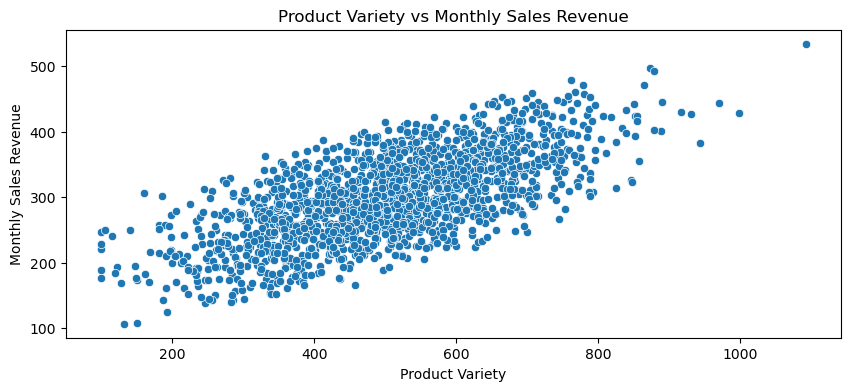

In [20]:
plt.figure(figsize = (10, 4))
sns.scatterplot(data = df, 
                x = 'ProductVariety', y = 'MonthlySalesRevenue')
plt.title('Product Variety vs Monthly Sales Revenue')
plt.xlabel('Product Variety')
plt.ylabel('Monthly Sales Revenue')
plt.show()

In [24]:
# Correlation Analysis
df[['ProductVariety','MonthlySalesRevenue']].corr()

,ProductVariety,MonthlySalesRevenue
ProductVariety,1.000000,0.674146
MonthlySalesRevenue,0.674146,1.000000


**Observation**

- A clear positive relationship exists between Product Variety and Monthly Sales Revenue.
- Stores offering a wider range of products consistently generate higher revenue.

#### <span style="color:#2e75b6; font-weight:bold;">Violin Plot: Revenue analysis across Categories</span>

<Axes: xlabel='StoreCategory', ylabel='MonthlySalesRevenue'>

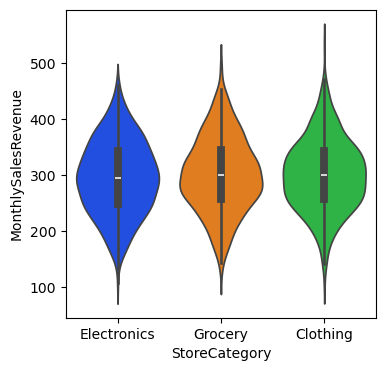

In [23]:
plt.figure(figsize=(4,4))
sns.violinplot(x='StoreCategory',
               y='MonthlySalesRevenue',
               data=df,
              palette = 'bright')

In [19]:
# Summary Stastistics
df.groupby('StoreCategory')['MonthlySalesRevenue'].describe()

,count,mean,std,min,25%,50%,75%,max
StoreCategory,,,,,,,,
Clothing,528.0,300.863125,63.920937,106.71,257.225,300.08,343.345,534.26
Electronics,535.0,295.390804,65.801259,107.16,248.800,294.51,343.275,461.17
Grocery,587.0,301.325571,66.697171,124.29,257.700,300.07,344.985,496.70


**Observation**
- The revenue distributions for Electronics, Grocery, and Clothing stores are very similar in shape.
- Median revenue for all three categories lies close to *300*.
- There is strong overlap between the distributions, suggesting no category clearly outperforms the others.

### <span style="color:#2e75b6; font-weight:bold;">Multivariate Analysis:</span> 

#### <span style="color:#2e75b6; font-weight:bold;">Scatter Plot: Monthly Sales Revenue vs Store Size by Store Location</span>

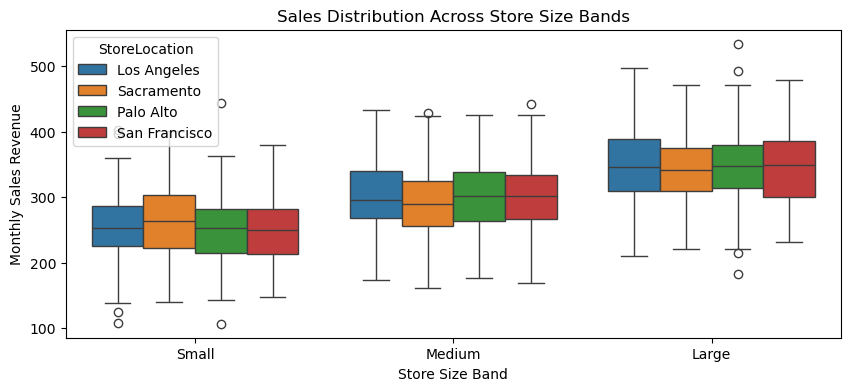

In [10]:
plt.figure(figsize = (10, 4))

sns.boxplot(data=df, x='SizeBand', y='MonthlySalesRevenue',hue = 'StoreLocation')
plt.title("Sales Distribution Across Store Size Bands")
plt.xlabel("Store Size Band")
plt.ylabel("Monthly Sales Revenue")
plt.show()

In [13]:
# Pivot Analysis
df.pivot_table(
    values='MonthlySalesRevenue',
    index='SizeBand',
    columns='StoreLocation',
    aggfunc='mean'
).round(2)

StoreLocation,Los Angeles,Palo Alto,Sacramento,San Francisco
SizeBand,,,,
Small,253.39,251.52,260.54,250.82
Medium,303.00,301.56,294.50,301.05
Large,347.07,346.88,342.38,344.04


**Observation**

- Revenue consistently increases as store size grows, with large stores outperforming small and medium stores across all locations.  
- While location causes slight variation in performance, store size appears to be the dominant factor influencing sales.

#### <span style="color:#2e75b6; font-weight:bold;">Bar Plot: Monthly Sales Revenue vs Competitor Distance by Store Category</span>

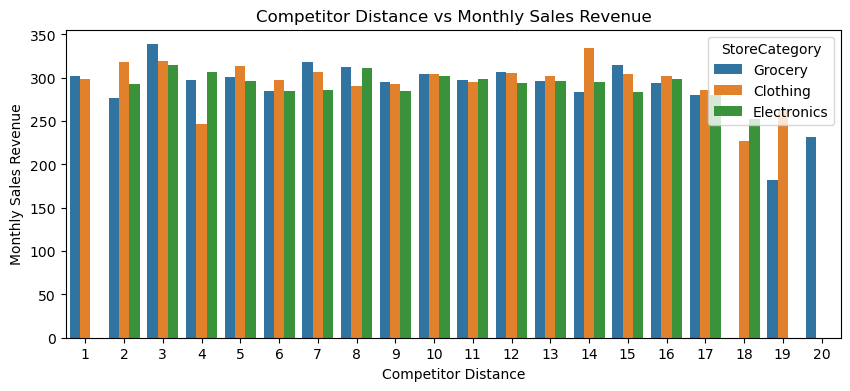

In [38]:
plt.figure(figsize = (10, 4))
sns.barplot(data = df, 
            x = 'CompetitorDistance', y = 'MonthlySalesRevenue', 
            ci = None, hue = 'StoreCategory')
plt.title('Competitor Distance vs Monthly Sales Revenue')
plt.xlabel('Competitor Distance')
plt.ylabel('Monthly Sales Revenue')
plt.show()

**Observation**

• Monthly sales stay fairly stable across competitor distances with no clear upward or downward trend.   
• Differences between store categories are also small, suggesting competitor distance alone doesn’t strongly drive revenue.

#### <span style="color:#2e75b6; font-weight:bold;">Line Plot: Monthly Sales Revenue vs Economic Indicator by Store Category of Top Performing Stores</span>

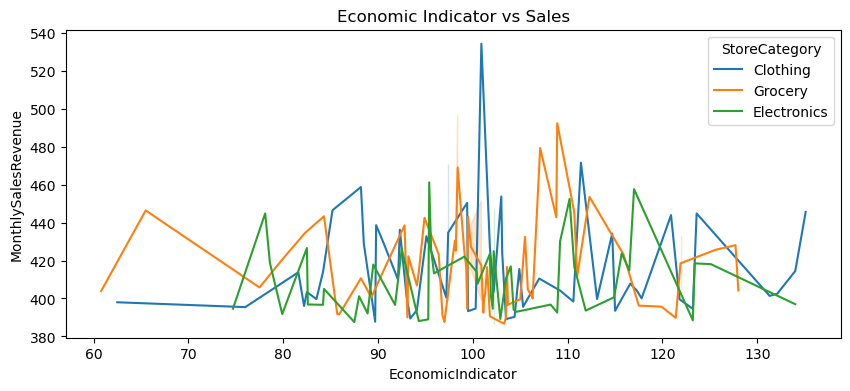

In [25]:
top_stores = df[df['MonthlySalesRevenue'] >= df['MonthlySalesRevenue'].quantile(0.90)]
plt.figure(figsize = (10, 4))
sns.lineplot(data = top_stores, 
             x = 'EconomicIndicator', y = 'MonthlySalesRevenue', 
             hue = 'StoreCategory')

plt.title('Economic Indicator vs Sales')
plt.show()

**Observation**

-  Even among top-performing stores, Monthly Sales Revenue does not show a consistent pattern with the Economic Indicator.
- Revenue fluctuates across all economic levels, suggesting store-level operational factors have stronger influence on sales than broader economic conditions.

#### <span style="color:#2e75b6; font-weight:bold;">Scatter Plot: Monthly Sales Revenue vs Marketing Spend by Store Category</span>

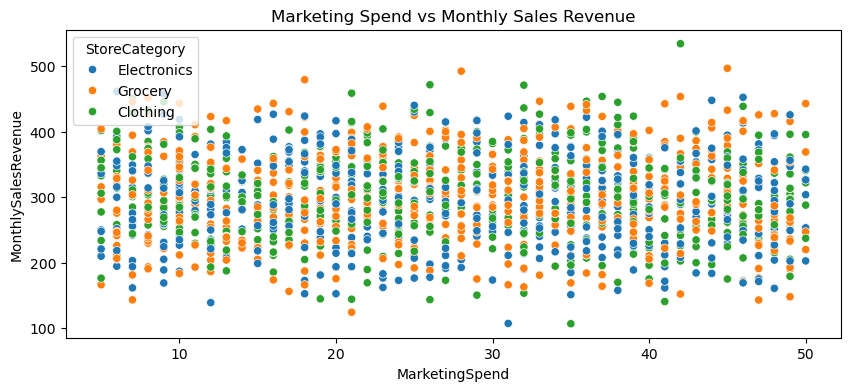

In [27]:
plt.figure(figsize = (10, 4))
sns.scatterplot(data = df, 
                x = 'MarketingSpend', y = 'MonthlySalesRevenue', 
                hue = 'StoreCategory')
plt.title('Marketing Spend vs Monthly Sales Revenue')
plt.show()

**Observation**

- Marketing spend does not show a strong linear relationship with monthly sales revenue, as data points remain widely scattered across all spending levels.  
- Similar revenue ranges appear across all store categories, suggesting marketing spend alone may not be a major driver of sales performance.

#### <span style="color:#2e75b6; font-weight:bold;">Correlation Matrix</span>

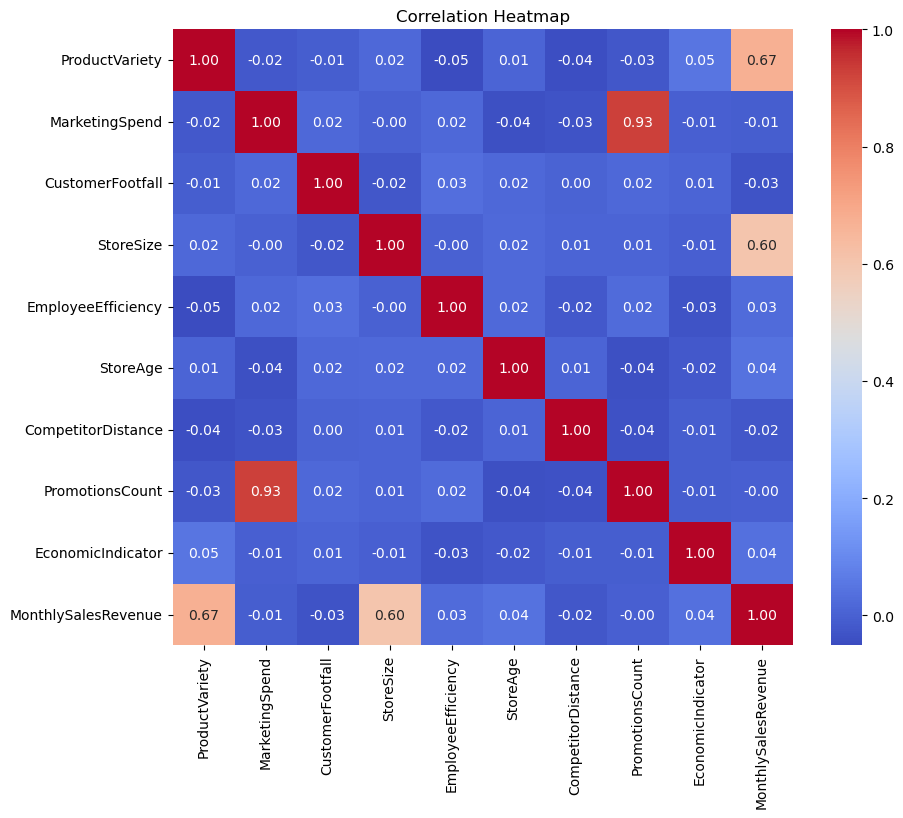

In [6]:
correlation_matrix = df.select_dtypes(include = 'number').corr()

plt.figure(figsize = (10, 8))
sns.heatmap(correlation_matrix, annot = True, 
            cmap = 'coolwarm', fmt = ".2f"
            )
plt.title('Correlation Heatmap')
plt.show()

**Observation**

- *Product Variety* (0.67) and *Store Size* (0.60) show the strongest positive correlation with revenue, while most other variables have negligible relationships.
- Most other variables (Store Age, Location, Competitor Distance, Economic Indicator, Employee Efficiency) show very weak correlation with revenue.


#### <span style="color:#2e75b6; font-weight:bold;">Pair Plot of Selected Numerical Variables</span>

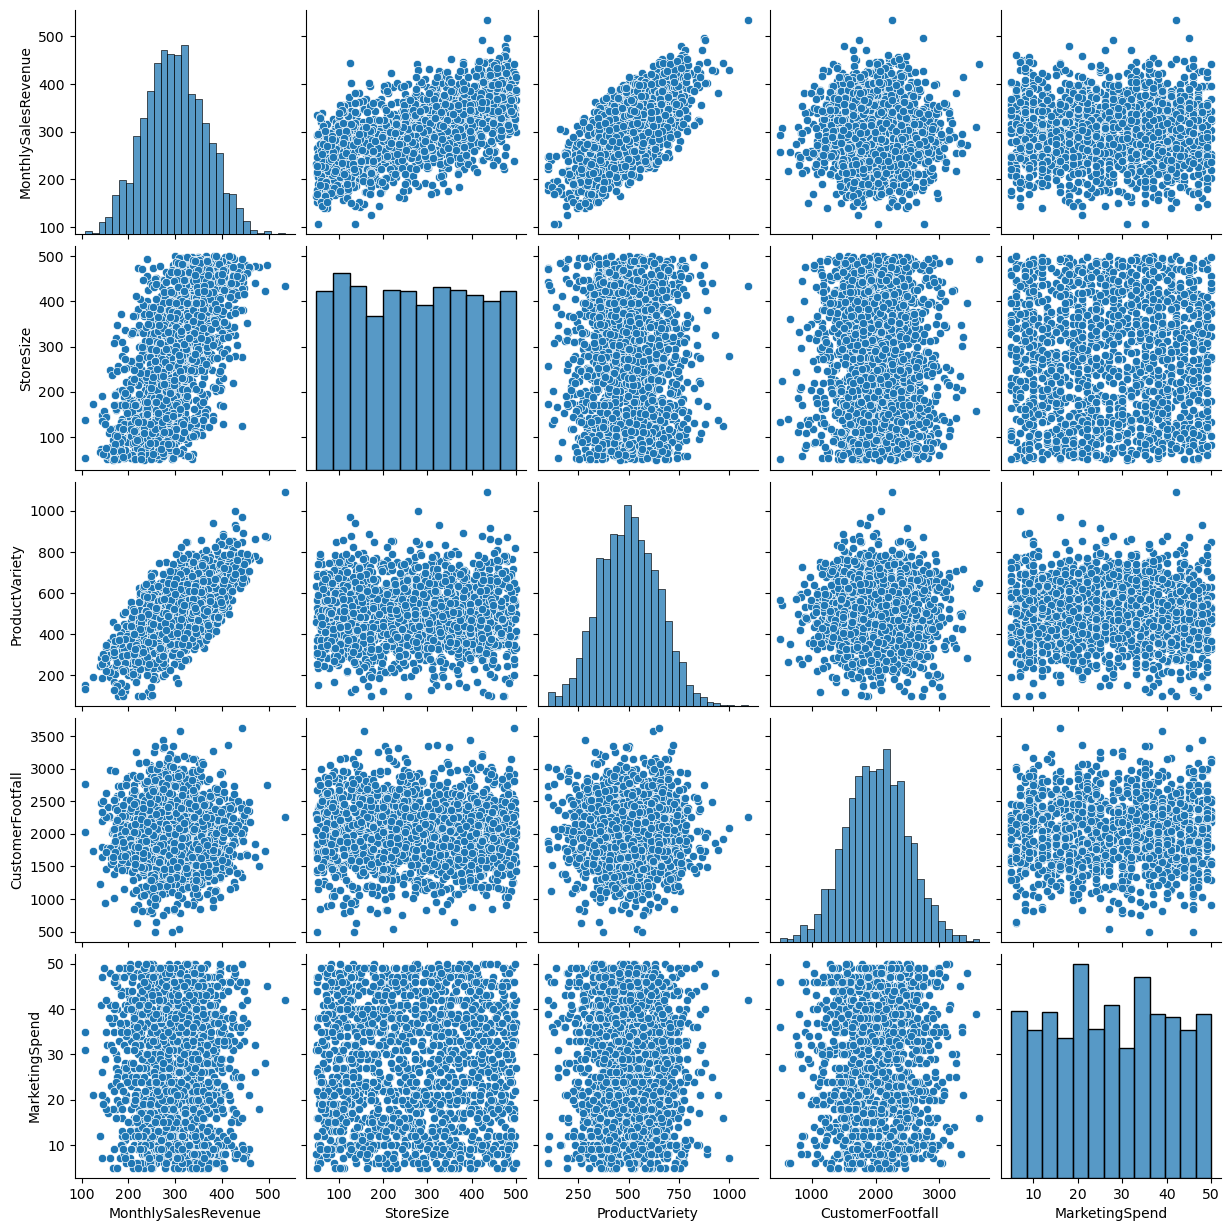

In [26]:
cols = [
    'MonthlySalesRevenue',
    'StoreSize',
    'ProductVariety',
    'CustomerFootfall',
    'MarketingSpend'
]
sns.pairplot(df[cols])
plt.show()

**Observation**

* Revenue shows clear positive relationships with *Product Variety* and *Store Size*, while other variables display weak or no visible trends.
* *Marketing Spend* appears widely scattered with no clear trend against sales.


## <span style="color:#1f4e79; font-weight:bold; font-size:20px;">📝 Insight Generation and Report</span>

#### <span style="color:#2e75b6; font-weight:bold;">📊 Key Drivers of Revenue</span> 

- Stores with **higher product variety** consistently generate more sales, showing that wider product selection improves customer purchasing.
- **Larger store size** also contributes to higher revenue, indicating that store capacity supports sales growth.
- Overall, revenue is mainly driven by **store capability** and **assortment**, not by external conditions.

#### <span style="color:#2e75b6; font-weight:bold;">⚠️ Factors with Weak Impact</span>  

- **Marketing spend** and **promotions** show little direct effect on revenue, even though they are strongly related to each other.
- **Customer footfall** does not strongly translate into sales, meaning more visitors alone do not guarantee higher revenue.
- **Economic indicator, competitor distance, store age, and employee efficiency** all show very weak relationships with revenue.
- This suggests that external environment and operational metrics alone are not the main sales drivers.

#### <span style="color:#2e75b6; font-weight:bold;">🔍 Hidden Business Insights</span> 

- Some stores show **high employee efficiency but low revenue**, suggesting operational productivity is not converting into sales performance.
- A few stores receive **high customer footfall but still report low sales**, indicating possible pricing, product mix, or conversion issues.
- **Older stores** dominate the dataset, yet age does not improve revenue, meaning experience alone does not ensure performance.
- **Promotions** also do not consistently boost revenue, implying they may not be well targeted.

#### <span style="color:#2e75b6; font-weight:bold;">🚀 Actionable Recommendations</span> 

- Increase product assortment in smaller or underperforming stores to improve revenue potential.
- Focus on **sales conversion strategies** (pricing, merchandising, product placement) rather than only driving footfall.
- Review stores with **high efficiency but low revenue** to identify sales process gaps.
- Re-evaluate promotion strategy to ensure campaigns target the right products and customer segments.
- Prioritize investments in **store expansion and assortment improvement**, as these show the strongest link to revenue.

## <span style="color:#1f4e79; font-weight:bold; font-size:20px;">📌 Conclusion</span>

This analysis shows that retail store performance is driven more by internal store factors such as product variety and store size than by external conditions or promotional spending. While marketing activity, customer traffic, and operational efficiency are important, they do not automatically translate into higher revenue without strong product strategy and store planning. The findings highlight the need for retailers to focus on assortment optimization, store capacity planning, and conversion improvement strategies to achieve sustainable revenue growth rather than relying only on promotions or external market conditions.